# 03 — Feature engineering

Technische und fundamentale Features mit Stichtag **vor** Q1 2024 (kein Lookahead). Die Pipeline nutzt `src.features.build_feature_matrix` — OHLCV bis einschließlich `config.FEATURE_CUTOFF_DATE`, Fundamentals aus dem yfinance-Cache.

**Voraussetzung:** OHLCV wie in Notebook 01/02 (Parquet-Cache); Fundamentals werden bei Bedarf nachgeladen.

In [1]:
from __future__ import annotations

import sys
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src.classifier import assign_groups, compute_q1_returns
from src.data_loader import download_ohlcv, load_fundamentals
from src.features import (
    FUNDAMENTAL_FEATURE_NAMES,
    TECHNICAL_FEATURE_NAMES,
    build_feature_matrix,
)
from src.universe import filter_by_min_volume, get_spi_extra_tickers

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)

## OHLCV und Liquiditätsfilter

Gleiche Logik wie Notebooks 01/02: Universum, optional `TICKER_LIMIT`, Parquet-Cache, dann `filter_by_min_volume`.

In [2]:
# None = alle SPI-Extra-Ticker; z. B. 30 für einen schnellen Smoke-Test
TICKER_LIMIT: int | None = None

all_tickers = get_spi_extra_tickers()
tickers = all_tickers if TICKER_LIMIT is None else all_tickers[:TICKER_LIMIT]

cache_dir = config.ensure_data_dir()
FORCE_REFRESH = False

ohlcv_by_ticker = download_ohlcv(
    tickers,
    start=config.YF_START,
    end=config.YF_END,
    cache_dir=cache_dir,
    force_refresh=FORCE_REFRESH,
    max_workers=8,
    retries=2,
)

if not ohlcv_by_ticker:
    raise RuntimeError(
        "Keine OHLCV-Daten — Netzwerk prüfen oder Notebook 01 einmal ausführen."
    )

liquid_tickers = filter_by_min_volume(ohlcv_by_ticker, config.MIN_DAILY_VOLUME_CHF)
ohlcv_liquid = {t: ohlcv_by_ticker[t] for t in liquid_tickers if t in ohlcv_by_ticker}

if not ohlcv_liquid:
    warnings.warn(
        "Keine Ticker nach Liquiditätsfilter — es werden alle geladenen Serien verwendet.",
        stacklevel=1,
    )
    ohlcv_liquid = ohlcv_by_ticker

print(f"Projekt: {PROJECT_ROOT}")
print(f"Feature-Cutoff (kein Lookahead): {config.FEATURE_CUTOFF_DATE}")
print(
    f"OHLCV: {len(ohlcv_by_ticker)} Ticker, "
    f"{len(ohlcv_liquid)} nach Liquiditätsfilter"
)

$ACHI.SW: possibly delisted; no timezone found

1 Failed download:
['ACHI.SW']: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AFP.SW"}}}
$AFP.SW: possibly delisted; no timezone found

1 Failed download:
['AFP.SW']: possibly delisted; no timezone found
$AIRE.SW: possibly delisted; no timezone found

1 Failed download:
['AIRE.SW']: possibly delisted; no timezone found
$ARON.SW: possibly delisted; no timezone found

1 Failed download:
['ARON.SW']: possibly delisted; no timezone found
$BALN.SW: possibly delisted; no timezone found

1 Failed download:
['BALN.SW']: possibly delisted; no timezone found
$BLS.SW: possibly delisted; no timezone found

1 Failed download:
['BLS.SW']: possibly delisted; no timezone found
$BOBNN.SW: possibly delisted; no timezone found

1 Failed download:
['BOBNN.SW']: possibly delisted; no timezone found
$BPDG.SW: possibly delisted; no timezone found

1 Fail

Projekt: /Users/stephangath/cursorAi/Stock Analysis AI
Feature-Cutoff (kein Lookahead): 2023-12-31
OHLCV: 154 Ticker, 136 nach Liquiditätsfilter


## Fundamentals laden

`load_fundamentals` pro Ticker (JSON-Cache unter `data/fundamentals/`). Parallel nur zur Job-Verteilung; yfinance-Aufrufe sind intern serialisiert.

In [3]:
def _load_fund_batch(
    tickers: list[str], *, cache_dir: Path, max_workers: int = 6
) -> dict[str, dict]:
    out: dict[str, dict] = {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {
            ex.submit(load_fundamentals, t, cache_dir=cache_dir, force_refresh=False): t
            for t in tickers
        }
        for fut in as_completed(futs):
            t = futs[fut]
            try:
                out[t] = fut.result()
            except Exception:
                out[t] = {}
    return out


ticker_list = list(ohlcv_liquid.keys())
fundamentals_by_ticker = _load_fund_batch(ticker_list, cache_dir=cache_dir)
n_nonempty = sum(1 for v in fundamentals_by_ticker.values() if v)
print(f"Fundamentals: {n_nonempty} / {len(ticker_list)} Ticker mit nicht-leerem .info")

Fundamentals: 136 / 136 Ticker mit nicht-leerem .info


## Feature-Matrix (`build_feature_matrix`)

Technische Indikatoren (`TECHNICAL_FEATURE_NAMES`) bis zum Cutoff; fundamentale Spalten (`FUNDAMENTAL_FEATURE_NAMES`) aus den geladenen `.info`-Dicts. Optional: Q1-2024-Labels anhängen für die spätere ML-Pipeline.

In [4]:
feature_matrix = build_feature_matrix(
    ohlcv_liquid,
    cutoff_date=config.FEATURE_CUTOFF_DATE,
    fundamentals_by_ticker=fundamentals_by_ticker,
)

q1_returns = compute_q1_returns(
    ohlcv_liquid,
    q_start=config.CLASS_Q_START,
    q_end=config.CLASS_Q_END,
)
labels = assign_groups(q1_returns, method="percentile")

labeled = feature_matrix.join(
    pd.DataFrame(
        {"q1_return": q1_returns, "group": labels},
    ),
    how="left",
)

print(
    f"Feature-Matrix: {feature_matrix.shape[0]} Zeilen × {feature_matrix.shape[1]} Spalten "
    f"(technisch {len(TECHNICAL_FEATURE_NAMES)} + fundamental {len(FUNDAMENTAL_FEATURE_NAMES)})"
)
print(f"Labeled-Tabelle: {labeled.shape[0]} × {labeled.shape[1]} (inkl. q1_return, group)")

Feature-Matrix: 136 Zeilen × 28 Spalten (technisch 18 + fundamental 10)
Labeled-Tabelle: 136 × 30 (inkl. q1_return, group)


## Inspektion

Stichprobe, beschreibende Statistik, fehlende Werte je Spalte, Korrelationsmatrix der numerischen Features.

In [5]:
feature_matrix.head(10)

,mom_1m,mom_3m,mom_6m,rsi_14,roc_10,sma_ratio_50_200,macd_diff_norm,adx_14,hvol_20d,hvol_60d,...,pe_ratio,pb_ratio,ev_ebitda,dividend_yield,revenue_growth,earnings_growth,roe,profit_margin,debt_equity,market_cap_log
ticker,,,,,,,,,,,,,,,,,,,,,
ADEN.SW,-0.010786,0.092956,0.380268,52.318258,0.267251,1.144563,-0.004361,26.012797,0.140321,0.321063,...,11.606250,1.005351,8.280,5.39,0.014,0.209,0.08422,0.01278,95.995,21.861341
AEVS.SW,-0.034286,-0.108179,-0.086487,43.386751,-2.873563,0.958338,0.000631,42.821835,0.246172,0.259767,...,450.000000,2.120974,61.843,NaN,0.157,NaN,-0.00701,0.00218,162.612,20.853937
ALLN.SW,0.037241,0.030137,-0.015707,57.532674,2.173911,0.967612,0.000782,28.760847,0.165004,0.179335,...,16.892400,1.350490,34.867,3.12,0.042,-0.289,0.08143,0.50218,97.439,22.033625
ALSN.SW,0.048017,0.088937,0.339381,55.243340,1.825558,1.160891,0.000506,28.211848,0.195676,0.223299,...,17.446270,1.518244,6.211,3.84,0.449,-0.121,0.09350,0.00810,57.140,21.286895
AMS.SW,0.503022,-0.088296,-0.388608,56.425217,11.292437,0.632031,0.008005,31.000136,0.775428,0.701313,...,NaN,0.978613,4.769,NaN,-0.007,NaN,-0.11819,-0.03912,329.747,20.555040
APGN.SW,0.051724,0.016667,-0.016129,60.889585,4.571429,0.964965,0.002488,34.111394,0.229980,0.215656,...,21.151716,7.866881,12.171,6.28,0.012,-0.191,0.35009,0.08235,NaN,20.165648
ARBN.SW,0.115875,0.147795,-0.048419,71.326162,17.726158,0.880326,0.010511,30.391780,0.376477,0.358174,...,NaN,0.412605,-3.832,14.45,NaN,NaN,-0.01162,0.21010,24.459,19.528910
ARYN.SW,-0.026959,-0.010204,0.036740,40.965006,-0.767263,1.056388,-0.003005,16.131784,0.287703,0.322572,...,1530.000000,2.996222,8.525,NaN,-0.002,0.008,0.22344,0.05051,129.524,21.141495
ASCN.SW,-0.187747,-0.209615,-0.243094,39.208202,0.611997,0.934021,0.002614,32.066241,0.959053,0.597859,...,11.904762,2.539360,NaN,4.00,0.052,18.077,NaN,0.05169,NaN,18.956041


In [6]:
feature_matrix.describe().T

,count,mean,std,min,25%,50%,75%,max
mom_1m,135.0,0.043571,0.085760,-0.187747,-0.002058,0.037821,0.082556,0.503022
mom_3m,135.0,0.027771,0.124594,-0.243750,-0.034356,0.010127,0.081670,0.654029
mom_6m,135.0,-0.002906,0.220263,-0.679454,-0.095938,-0.003495,0.059621,1.492857
rsi_14,135.0,56.662646,10.620688,26.368093,49.964964,57.936457,63.638471,86.061678
roc_10,135.0,2.660244,4.480624,-12.531328,0.000000,2.032087,5.646928,17.726158
sma_ratio_50_200,135.0,0.960825,0.121205,0.355288,0.918283,0.968284,1.000298,1.654639
macd_diff_norm,135.0,0.000735,0.005348,-0.042521,-0.001269,0.000886,0.003119,0.016264
adx_14,135.0,26.752185,11.287838,7.617816,18.927382,25.423598,33.654374,63.043553
hvol_20d,135.0,0.265700,0.201821,0.064283,0.146865,0.213060,0.317126,1.492626
hvol_60d,135.0,0.283518,0.182436,0.073351,0.171756,0.243454,0.329194,1.216975


In [7]:
nan_pct = (feature_matrix.isna().mean() * 100).sort_values(ascending=False)
nan_pct.to_frame("missing_pct")

,missing_pct
earnings_growth,32.352941
debt_equity,23.529412
ev_ebitda,22.058824
pe_ratio,20.588235
dividend_yield,17.647059
roe,4.411765
revenue_growth,2.941176
mom_1m,0.735294
mom_3m,0.735294
profit_margin,0.735294


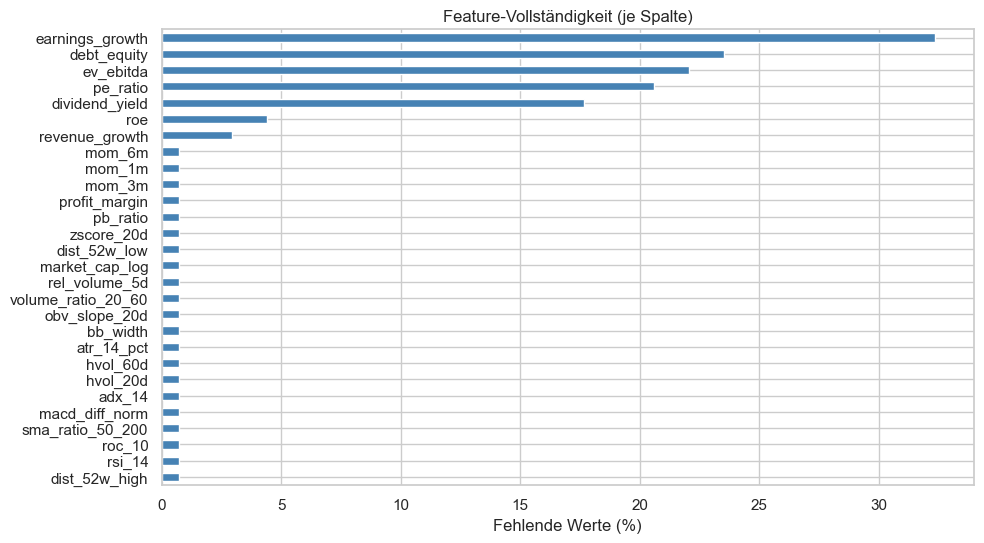

In [8]:
fig, ax = plt.subplots(figsize=(10, max(4, len(nan_pct) * 0.2)))
nan_pct.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Fehlende Werte (%)")
ax.set_title("Feature-Vollständigkeit (je Spalte)")
plt.tight_layout()
plt.show()

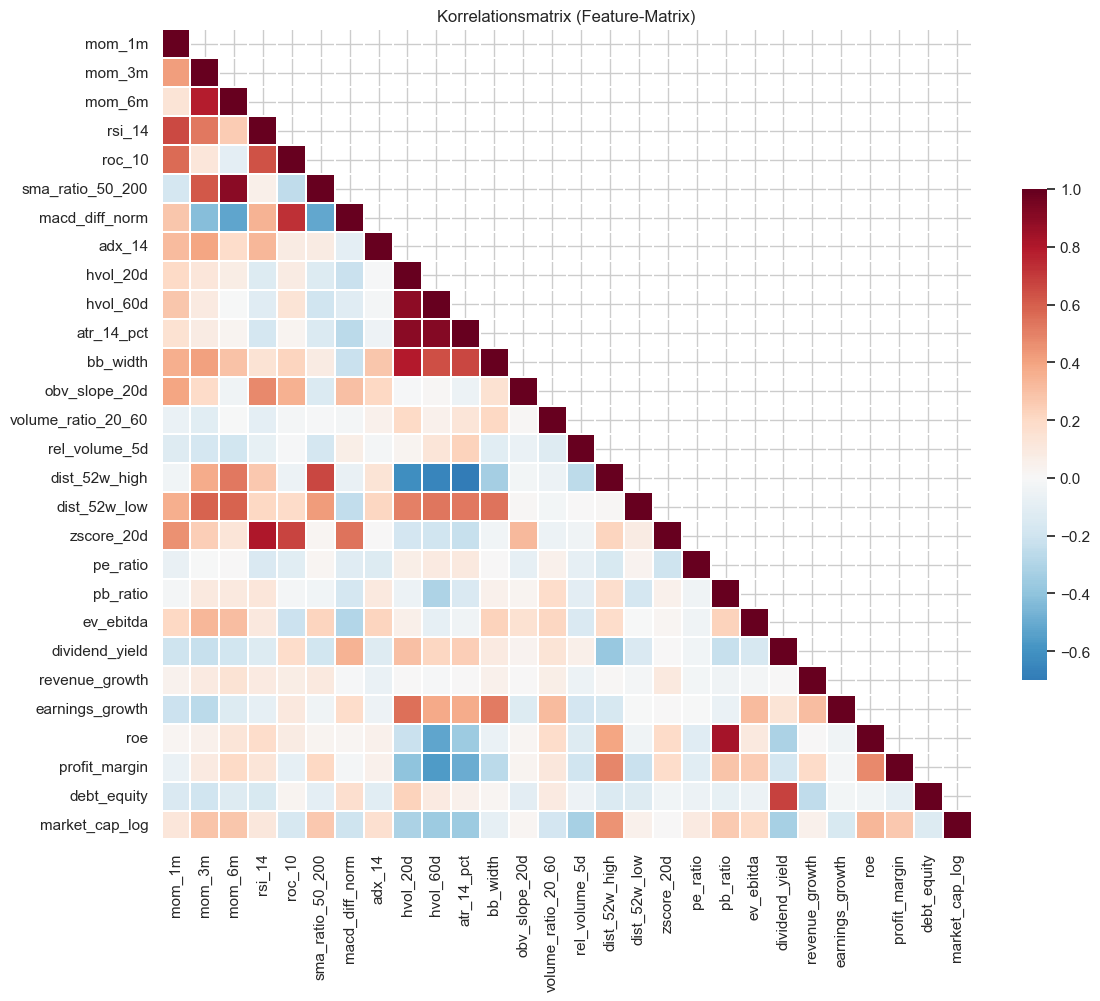

In [9]:
# Korrelation nur für Spalten mit ausreichend nicht-NaN-Paaren
corr = feature_matrix.dropna(axis=1, how="all").corr(numeric_only=True)
# Bei vielen NaNs kann corr leer sein — min_periods absichern
if not corr.empty and corr.shape[0] > 1:
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr,
        mask=mask,
        cmap="RdBu_r",
        center=0,
        square=True,
        linewidths=0.2,
        cbar_kws={"shrink": 0.6},
    )
    plt.title("Korrelationsmatrix (Feature-Matrix)")
    plt.tight_layout()
    plt.show()
else:
    print("Korrelationsmatrix übersprungen (zu wenige gültige Spalten/Paare).")

In [10]:
# Gelabelte Stichprobe (ML-Input in späteren Notebooks)
labeled.dropna(subset=["group"]).head(12)

,mom_1m,mom_3m,mom_6m,rsi_14,roc_10,sma_ratio_50_200,macd_diff_norm,adx_14,hvol_20d,hvol_60d,...,ev_ebitda,dividend_yield,revenue_growth,earnings_growth,roe,profit_margin,debt_equity,market_cap_log,q1_return,group
ticker,,,,,,,,,,,,,,,,,,,,,
ADEN.SW,-0.010786,0.092956,0.380268,52.318258,0.267251,1.144563,-0.004361,26.012797,0.140321,0.321063,...,8.280,5.39,0.014,0.209,0.08422,0.01278,95.995,21.861341,-0.117545,Losers
AEVS.SW,-0.034286,-0.108179,-0.086487,43.386751,-2.873563,0.958338,0.000631,42.821835,0.246172,0.259767,...,61.843,NaN,0.157,NaN,-0.00701,0.00218,162.612,20.853937,-0.097633,Losers
ALLN.SW,0.037241,0.030137,-0.015707,57.532674,2.173911,0.967612,0.000782,28.760847,0.165004,0.179335,...,34.867,3.12,0.042,-0.289,0.08143,0.50218,97.439,22.033625,0.048780,Steady
ALSN.SW,0.048017,0.088937,0.339381,55.243340,1.825558,1.160891,0.000506,28.211848,0.195676,0.223299,...,6.211,3.84,0.449,-0.121,0.09350,0.00810,57.140,21.286895,-0.060241,Losers
AMS.SW,0.503022,-0.088296,-0.388608,56.425217,11.292437,0.632031,0.008005,31.000136,0.775428,0.701313,...,4.769,NaN,-0.007,NaN,-0.11819,-0.03912,329.747,20.555040,-0.476250,Losers
APGN.SW,0.051724,0.016667,-0.016129,60.889585,4.571429,0.964965,0.002488,34.111394,0.229980,0.215656,...,12.171,6.28,0.012,-0.191,0.35009,0.08235,NaN,20.165648,0.214286,Winners
ARBN.SW,0.115875,0.147795,-0.048419,71.326162,17.726158,0.880326,0.010511,30.391780,0.376477,0.358174,...,-3.832,14.45,NaN,NaN,-0.01162,0.21010,24.459,19.528910,0.312296,Winners
ARYN.SW,-0.026959,-0.010204,0.036740,40.965006,-0.767263,1.056388,-0.003005,16.131784,0.287703,0.322572,...,8.525,NaN,-0.002,0.008,0.22344,0.05051,129.524,21.141495,0.077683,Steady
ASCN.SW,-0.187747,-0.209615,-0.243094,39.208202,0.611997,0.934021,0.002614,32.066241,0.959053,0.597859,...,NaN,4.00,0.052,18.077,NaN,0.05169,NaN,18.956041,0.040455,Steady
